In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullFormatter
plt.rcParams['font.size'] = 12

# manifold.TSNE
from sklearn import manifold  #, datasets
from time import time

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

## Data and labels 
In this example we know the labels, hence we can test the performances of t-SNE and DBSCAN

In [57]:
fname,fnamey="x_12d.dat","y_12d.dat" 
data=np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y=np.loadtxt("DATA/"+fnamey,dtype=int)
N=len(data) #number of data points
D=len(data[0]) #number of features
print("N=",N,"  L=D=",D)
x=data

N= 600   L=D= 12


## Find the typical minimum distance between points
This yields a typical scale, to be used as a reference for "eps" (radius)

[  0.         145.92274307 161.446568   175.02075719 184.83502833
 186.6121665  187.18824319 219.69258419 224.1511747  242.6862013
 284.09295507] range(0, 599)
(11, 600)


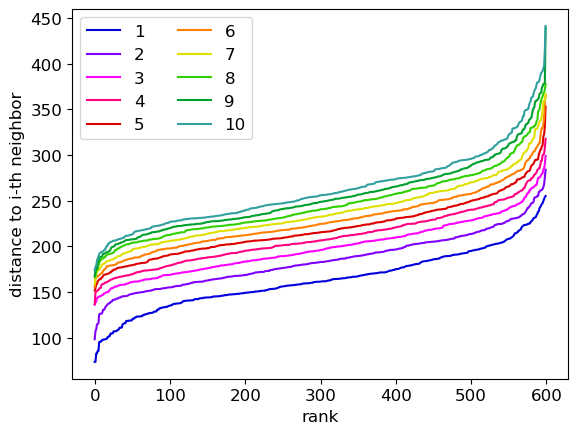

mean minimum distance between nn points:  163.65491354345073


In [3]:
#---> for each sample, sort all neighbours by distance, and pick the first one; then the second one; etc

nn = 10
# compute the distance to the nn nearest neighbors
nbrs = NearestNeighbors(n_neighbors=nn+1).fit(x) #, algorithm='ball_tree'
# distances and the indices of the nn nearest neighbors (10+1)
d, ind = nbrs.kneighbors(x) # returns distances and indices of nn neighbors
print(d[3,:],range(ind.max()))
dd=d.T # distances to the i-th neighbor for all points, sorted by distance
print(dd.shape)
# note: dd[0] has a trivial set of zeros
listc= ["#0000DD","#8000FF","#FF00FF","#FF0080","#DD0000",
        "#FF8000","#E0E000","#30D000","#00A030","#33A0A0"]
for i in range(1,nn+1):
    plt.plot(np.sort(dd[i]),c=listc[i-1],label=str(i))
    plt.xlabel("rank")
    plt.ylabel("distance to i-th neighbor")
plt.legend(ncol=2)
plt.show()
mean_min_dist = np.mean(dd[1]) # mean distance to the NEAREST (first) neighbor
print("mean minimum distance between nn points: ",mean_min_dist)

## t-SNE visualization, for true labels

---> also a clusteting algo!
remember perplexity is *how many points define a neighbourhood*, also called local entropy; high perplexity <-> bigger clusters

t-SNE with perplexity=2: 3.2 sec
t-SNE with perplexity=4: 2.4 sec
t-SNE with perplexity=8: 2.6 sec
t-SNE with perplexity=16: 2.6 sec
t-SNE with perplexity=32: 3.3 sec


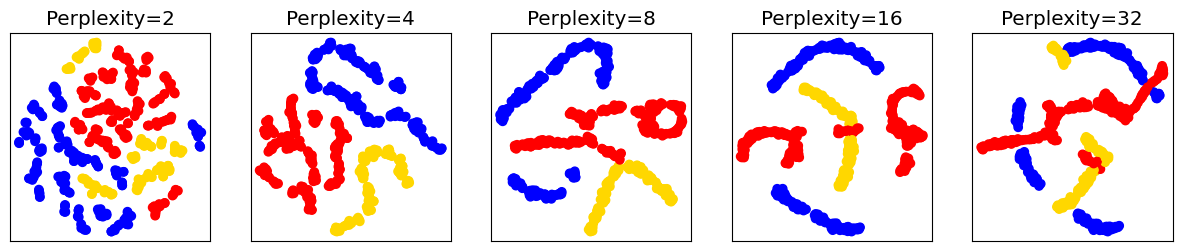

In [4]:
np.random.seed(0)
n_samples = N # number of data points to consider
n_components = 2 # dimension of the embedded space
perplexities = [2, 4, 8, 16, 32]
Np = len(perplexities)
mycmap = ListedColormap(["blue","red","gold" ])

(fig, subplots) = plt.subplots(1,Np , figsize=(3*Np, 2.7))

X_all = [None]
for i, perplexity in enumerate(perplexities):
    ax = subplots[i]

    t0 = time()
    tsne = manifold.TSNE(n_components=n_components, init='random',
                         random_state=0, perplexity=perplexity, learning_rate='auto')
    Y = tsne.fit_transform(data) # apply t-SNE to the data
    t1 = time() # time taken by t-SNE
    print("t-SNE with perplexity=%d: %.2g sec" % (perplexity, t1 - t0))
    ax.set_title("Perplexity=%d" % perplexity)
    ax.scatter(Y[:, 0], Y[:, 1], c=y,cmap=mycmap) # plot the t-SNE embedding
    ax.tick_params(left=False,bottom=False)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.axis('tight')
    X_all.append(Y)
    
plt.show()

# ---> colors from data, NOT inferred by algo(?)

## Different random initial states (random_state=i)

---> bc tSNE highly subject to init conds: try multiple ones

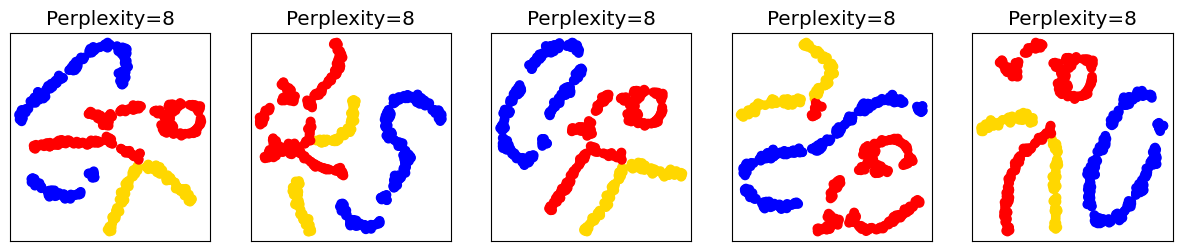

In [5]:
n_samples = N
n_components = 2 
mycmap = ListedColormap(["blue","red","gold" ])

(fig, subplots) = plt.subplots(1,Np , figsize=(3*Np, 2.7))

X_all = [None]

perplexity= 8

for i in range(5):
    np.random.seed(i) 
    ax = subplots[i]

    t0 = time()
    tsne = manifold.TSNE(n_components=n_components, 
                         init='random',random_state=i, 
                         perplexity=perplexity)
    Y = tsne.fit_transform(data)
    t1 = time()
    ax.set_title("Perplexity=%d" % perplexity)
    ax.scatter(Y[:, 0], Y[:, 1], c=y,cmap=mycmap)
    ax.tick_params(left=False,bottom=False)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.axis('tight')
    X_all.append(Y) # store the t-SNE embedding for later use
    
plt.show()

## DBSCAN: find labels by applying clustering

---> compare known correct clusters (labelled original data) with DBSCAN output

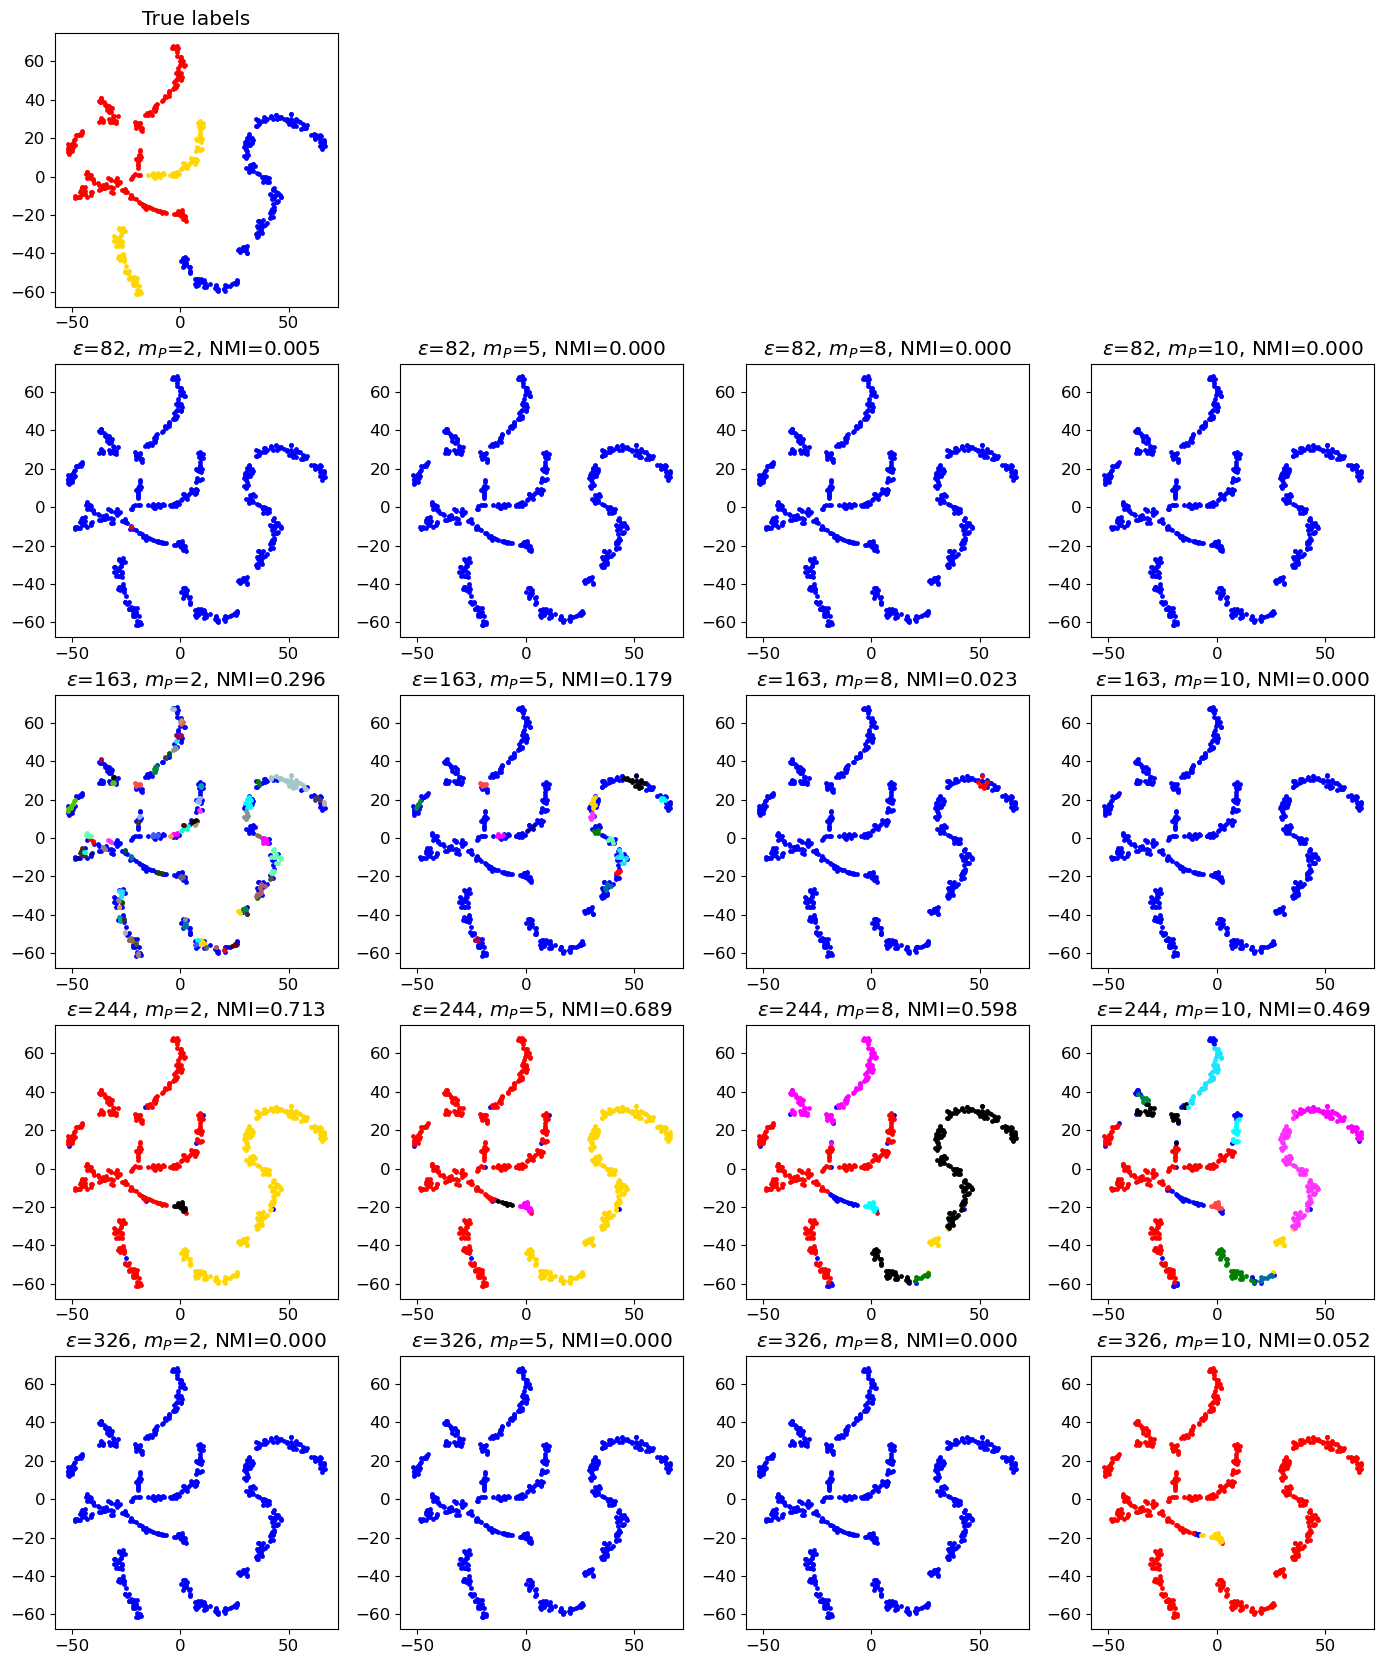

In [6]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
cpalette = ["blue","red","gold","black","magenta","green","cyan","#1CE6FF", "#FF34FF", "#FF4A46","#008941", "#006FA6", "#A30059", "#0000A6", "#63FFAC","#B79762", "#004D43", "#8FB0FF", "#997D87","#5A0007", "#809693","#1B4400", "#4FC601", "#3B5DFF", "#4A3B53","#886F4C","#34362D", "#B4A8BD", "#00A6AA", "#452C2C","#636375", "#A3C8C9", "#FF913F", "#938A81","#575329", "#00FECF", "#B05B6F"]
from collections import OrderedDict
ms = 6

def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the shannon entropy of a cluster
    # c is a dictinary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

# Normalized mutual information function
# Note that this deals with the label permutation problem
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

def plotting_ax(X, y, ax):
    # plotting function
    for i, yu in enumerate(np.unique(y)):
        pos = (y == yu)
        ax.scatter(X[pos,0], X[pos,1],c=cpalette[i%len(cpalette)],s=ms)

# DBSCAN has a few parameters, let's sweep over a few parameters and see what happens
np.random.seed(12345)
n_true_center=3 
#X, ytrue = make_blobs(10000, 2, n_true_center) # Generating random gaussian mixture
X2D = X_all[2] # best(?) visualization of the data in 2D, obtained by t-SNE with perplexity=8
X = data
y_true = y

#eps_range = [0.01,0.1,0.5,1.0,10.]
if mean_min_dist<10:
    r=mean_min_dist # mean minimum distance between nn points
else:
    r = int(mean_min_dist)
eps_range = [r/2,r,1.5*r,2*r] # range of eps values to try

min_sample_range = [2,5,8,10] 
DIMY=len(eps_range) 
DIMX=len(min_sample_range)
fig, ax = plt.subplots(DIMY+1,DIMX,figsize=(14,16.8))

i,j=0,0
nmi=1
plotting_ax(X2D,y,ax[i,j])
ax[i,j].set_title('True labels')
for j in range(1,DIMX): fig.delaxes(ax[i,j])
    
for i, eps in enumerate(eps_range):
    for j, min_samples in enumerate(min_sample_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        model.fit(X)
        y_hat = model.labels_ # predicted labels
        plotting_ax(X2D,y_hat,ax[i+1,j])
        nmi=NMI(y_hat, y_true)
        ax[i+1,j].set_title(r'$\epsilon$=%.0f, $m_P$=%i, NMI=%.3f'%(eps,min_samples,nmi))

plt.tight_layout(h_pad=0.5)
plt.show()


---> becomes decent when eps big enough.

NB should change other params to get better results

## Try PCA algorithm on unlabelled dataset (Exercise 4.2)

In [1]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [2]:
fname,fnamey="x_12d.dat","y_12d.dat"
data=np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y=np.loadtxt("DATA/"+fnamey,dtype=int)

In [3]:
#keep the components explaining 95% of variance:
var_list=[]
for i in range(1, data.shape[1]+1):
    #print(i)
    data_reduced = PCA(n_components=i).fit(data)
    var = np.cumsum(data_reduced.explained_variance_ratio_)[-1]
    #print(var)
    var_list.append(var)

In [4]:
print(list(range(1, data.shape[1])))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


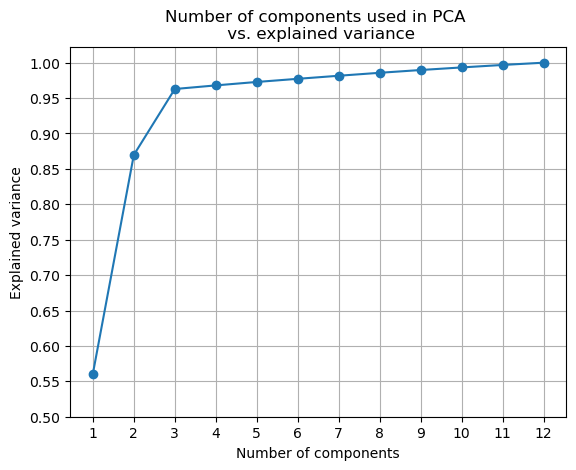

In [5]:
plt.plot(np.arange(1, data.shape[1]+1), var_list, marker='o')
plt.xticks(np.arange(1,12.5,1))
plt.yticks(np.arange(0.5, 1.01, 0.05))  # ticks from 0 to 1 in steps of 0.1
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title("Number of components used in PCA \n vs. explained variance")
plt.grid(True)
plt.show()

In [6]:
n_cps=3

In [7]:
data_reduced_3=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

In [8]:
print(data.shape,data_reduced_3.shape)
#print(data[10:,:])
#print(data_reduced[:10,:])

(600, 12) (600, 3)


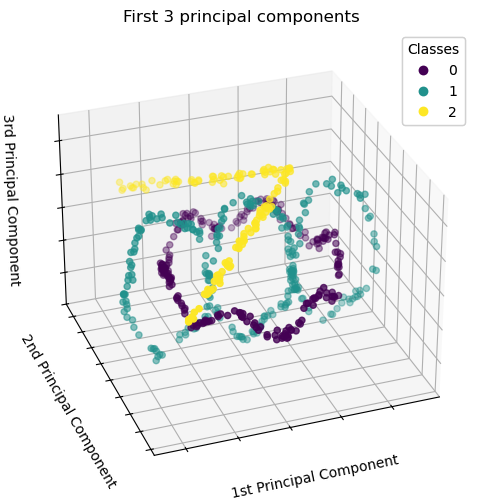

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)


scatter = ax.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True#,
    #s=40,
)

ax.set(
    title=f"First {n_cps} principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend3 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend3)

plt.show()


In [10]:
n_cps=2
data_reduced=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

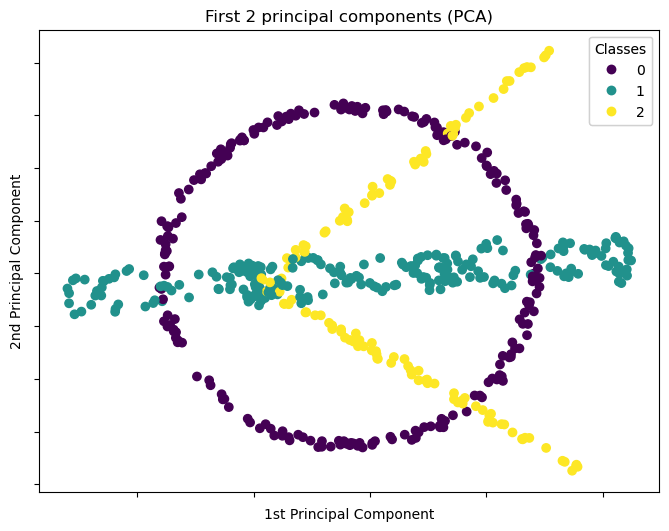

In [11]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)#, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    data_reduced[:, 0],
    data_reduced[:, 1],
    #data_reduced[:, 2],
    c=y#,
    #s=40,
)

ax.set(
    title=f"First {n_cps} principal components (PCA)",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    #zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
#ax.zaxis.set_ticklabels([])

# Add a legend
legend2 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend2)

plt.show()

In [12]:
n_cps=1
data_reduced=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

In [13]:
data_reduced.shape

(600, 1)

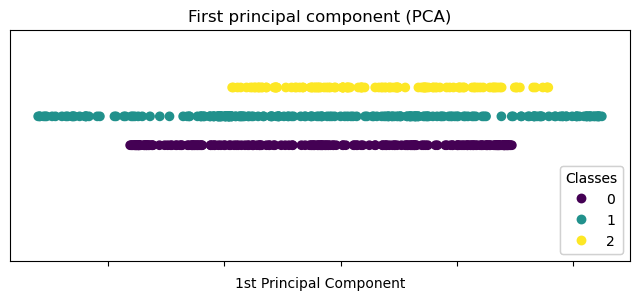

In [14]:
fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(111)#, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    data_reduced[:, 0],
    #data_reduced[:, 1],
    #data_reduced[:, 2],
    y=y/4,#np.zeros(data_reduced.shape[0]),
    #---> for plotting
    c=y
    #s=40,
)

ax.set(
    title="First principal component (PCA)",
    xlabel="1st Principal Component",
    ylim=[-1,1]
    #ylabel="2nd Principal Component",
    #zlabel="3rd Principal Component",
)

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.yaxis.set_ticks([])
#ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="lower right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

In [15]:
# ---> TODO: get NMI or similar to numerically (using labels) say how good??

## Try K-means clustering on labelled dataset (Exercise 4.3)

We fix the number of clusters $k=3$. We perform PCA beforehand, in order to make sure that K-means doesn't worry about the noise components when picking clusters.

In [16]:
from sklearn.cluster import KMeans
from collections import OrderedDict

In [17]:
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the shannon entropy of a cluster
    # c is a dictinary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

In [18]:
kmeans=KMeans(n_clusters=3, init='random', n_init=10, max_iter=300, tol=0.0001, verbose=1, algorithm='lloyd').fit(data_reduced_3)
y_hat=kmeans.labels_

Initialization complete
Iteration 0, inertia 295189034.85178494.
Iteration 1, inertia 182867532.14413318.
Iteration 2, inertia 168057946.19278103.
Iteration 3, inertia 156187036.04881877.
Iteration 4, inertia 148571169.76753426.
Iteration 5, inertia 147012627.72086877.
Iteration 6, inertia 146431120.36010367.
Iteration 7, inertia 146118638.13790172.
Iteration 8, inertia 146054335.92259336.
Iteration 9, inertia 146042312.53154847.
Converged at iteration 9: strict convergence.
Initialization complete
Iteration 0, inertia 297569049.0277664.
Iteration 1, inertia 164787713.5708844.
Iteration 2, inertia 159488797.21914124.
Iteration 3, inertia 158474914.88649893.
Iteration 4, inertia 156834966.86902052.
Iteration 5, inertia 154193565.23437876.
Iteration 6, inertia 151717457.27127847.
Iteration 7, inertia 150998924.10803163.
Iteration 8, inertia 150744613.7412503.
Iteration 9, inertia 150712207.44830912.
Converged at iteration 9: strict convergence.
Initialization complete
Iteration 0, inerti

In [19]:
centroids=kmeans.cluster_centers_

In [20]:
y_hat=kmeans.predict(data_reduced_3)
nmi=NMI(y_hat, y)
print(nmi)
print(data_reduced_3.shape)

0.12624616836895278
(600, 3)


C:\Users\Libero\AppData\Local\Temp\ipykernel_15584\3027106974.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


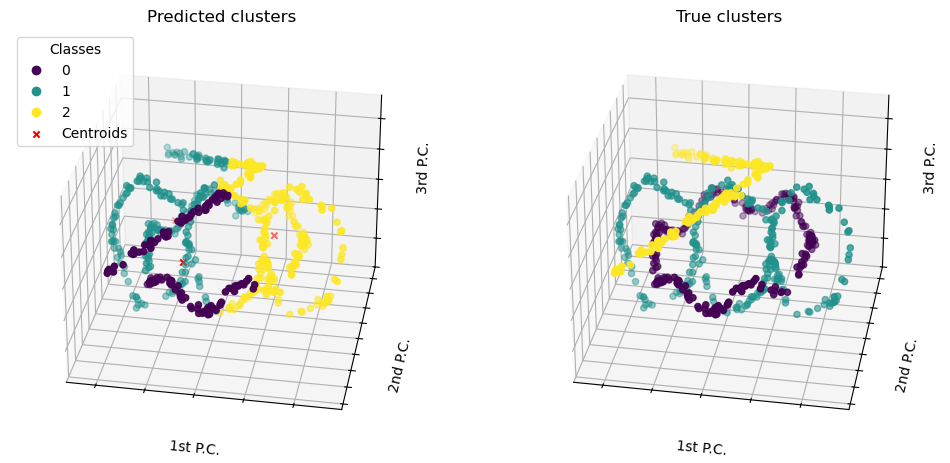

In [21]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2 , projection="3d", elev=-150, azim=80)

scatter1=ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)

scatter1b=ax1.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker='x', c='r', label="Centroids")

ax1.set(
    title="Predicted clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)

ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

handles1, labels1 = scatter1.legend_elements()
handles1.append(scatter1b)
labels1.append("Centroids")
ax1.legend(handles1, labels1, title="Classes", loc="upper left")

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True#,
    #s=40,
)

ax2.set(
    title="True clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

# Add a legend
#handles2, labels2 = scatter2.legend_elements()
#ax2.legend(handles2, labels2, title="Classes", loc="upper left")

plt.tight_layout()
plt.show()

In [22]:
print(centroids, '\n\n', nmi)

[[ 202.88801587 -625.1590131   -53.30052008]
 [ 494.62819643  258.48251715   31.0185643 ]
 [-576.99621345   61.0690535    -3.44262164]] 

 0.12624616836895278


## Try hierarchical clustering (Exercise 4.4)

As before, we perform PCA beforehand.

In [23]:
from sklearn.cluster import AgglomerativeClustering as HC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd

In [24]:
my_linkages=['ward', 'complete', 'average', 'single']
my_metrics=['euclidean', 'l1', 'l2', 'manhattan', 'cosine']
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data_reduced_3) # ---> rescale 3d (post-PCA) data for better implementation

### Compare different metrics and linkages to find best output

In [25]:
best_model=''
scores=[]
models=[]
score_best=-1e9
for mc in my_metrics:
    for lk in my_linkages:
        if ((lk=='ward') and (mc!='euclidean')): continue
        hc_model=HC(n_clusters=3, metric=mc, linkage=lk, compute_distances=True)
        cluster_labels = hc_model.fit_predict(scaled_data)
        #pd.Series(cluster_labels).value_counts()
        sil_score = silhouette_score(scaled_data, cluster_labels)
        #print("Score :", round(sil_score, 2))
        if (sil_score>score_best):
            score_best=sil_score
            best_model=hc_model
        scores.append(sil_score)

In [26]:
print([float(score) for score in scores], '\n')
print(score_best, '\n')
print(best_model, '\n')

y_hat=best_model.labels_
nmi=NMI(y_hat, y)
print(nmi)

[0.24823705024006765, 0.22563397535244167, 0.25839096239442594, -0.016089411498138712, 0.23692604071712647, 0.2526619005787232, -0.016089411498138712, 0.22563397535244167, 0.25839096239442594, -0.016089411498138712, 0.23692604071712647, 0.2526619005787232, -0.016089411498138712, 0.26480713630063074, 0.27899310356666435, -0.36661353814472475] 

0.27899310356666435 

AgglomerativeClustering(compute_distances=True, linkage='average',
                        metric='cosine', n_clusters=3) 

0.25158051075398297


In [27]:
#---> TODO: plot results (heatmap)??

### Visualise the dendrogram
(for the best model).

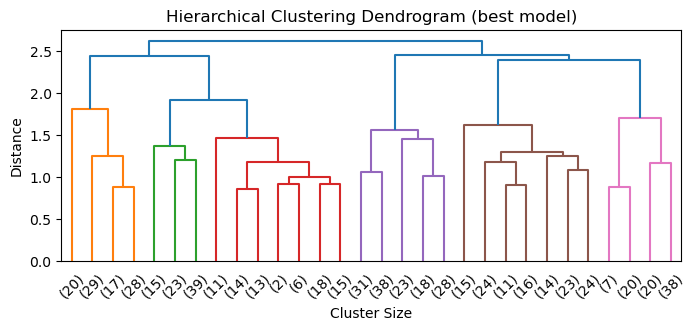

In [28]:
linked = linkage(scaled_data, method='average')

plt.figure(figsize=(8, 3))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)
plt.title("Hierarchical Clustering Dendrogram (best model)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

C:\Users\Libero\AppData\Local\Temp\ipykernel_15584\4073233508.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


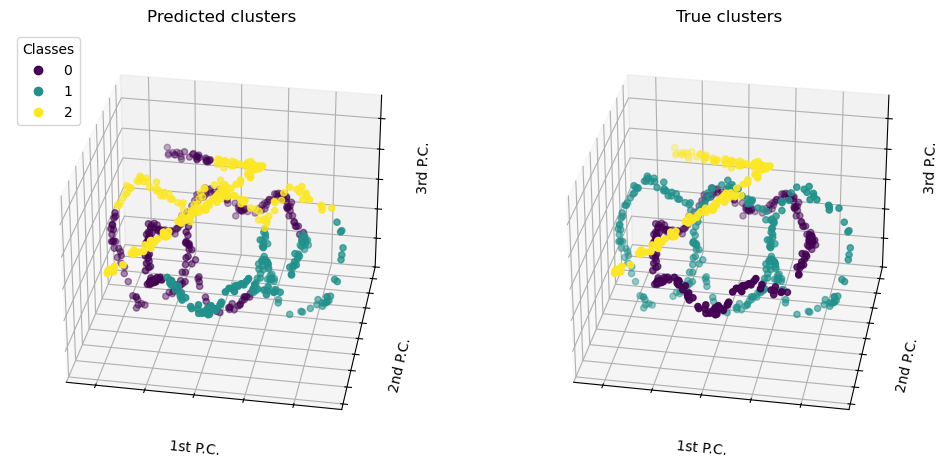

In [29]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2 , projection="3d", elev=-150, azim=80)

scatter1=ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)

ax1.set(
    title="Predicted clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)

ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

handles1, labels1 = scatter1.legend_elements()
ax1.legend(handles1, labels1, title="Classes", loc="upper left")

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True#,
    #s=40,
)

ax2.set(
    title="True clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

# Add a legend
#handles2, labels2 = scatter2.legend_elements()
#ax2.legend(handles2, labels2, title="Classes", loc="upper left")

plt.tight_layout()
plt.show()

### Try spectral clustering (Exercise 4.5)

Performs clustering (eg with k-means) on a *map* of original data (a projection of the normalized Laplacian), to distinguish clusters by their characteristic shape. As before, we perform PCA beforehand.

In [47]:
from sklearn.cluster import SpectralClustering as SC
from sklearn.manifold import SpectralEmbedding as SE #---> for visualisation later

In [31]:
print(scaled_data.shape)

(600, 3)


In [32]:
gammas=[0.001,0.01,0.1,1,10,100]
nmi_list=[]
nmi_best=-0.1
gamma_best=0

# rbf kernel with different gammas
for g in gammas:
    y_hat=SC(n_clusters=3,
       n_init=10, # number of iters for assigning_labels='kmeans'
       gamma=g, # kernel coefficient for rbf, poly, sigmoid, laplacian and chi2 kernels
       eigen_solver='arpack', # computational strategy ('arpack' is deterministic)
       affinity='rbf', # kernel to use to calculate the affinity matrix
       n_neighbors=10, # for nearest-neighbor method of assigning labels
       eigen_tol='auto', # eigen_tol=0.0 for arpack
       assign_labels='kmeans', # strategy to assign labels, ie to perform clustering in the embedded space
       degree=3, # degree for poly kernel only
       coef0=1, # for poly and sigmoid kernels only
       verbose=False).fit_predict(scaled_data)
    nmi=NMI(y_hat,y)
    if (nmi>nmi_best):
        nmi_best=nmi
        gamma_best=g
    nmi_list.append(nmi)
print([float(n) for n in nmi_list], '\n')

[0.21434750471469416, 0.214660245960514, 0.20584074437890154, 0.25635226467216754, 0.46565193644674907, 0.711498405773882] 



In [33]:
print(nmi_best)
print(gamma_best)

0.711498405773882
100


In [34]:
# nearest neighbors kernel
y_hat=SC(n_clusters=3,
   n_init=10, # number of iters for assigning_labels='kmeans'
   eigen_solver='arpack', # computational strategy ('arpack' is deterministic)
   affinity='nearest_neighbors', # kernel to use to calculate the affinity matrix
   n_neighbors=10, # for nearest-neighbor method of assigning labels
   eigen_tol='auto', # eigen_tol=0.0 for arpack
   assign_labels='kmeans', # strategy to assign labels, ie to perform clustering in the embedded space
   verbose=False).fit_predict(scaled_data)
nmi=NMI(y_hat,y)
print(nmi)

0.9617394647100065


In [35]:
#---> TODO: further improve (but might be overfitting)?

(5,)


C:\Users\Libero\AppData\Local\Temp\ipykernel_15584\2991958957.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


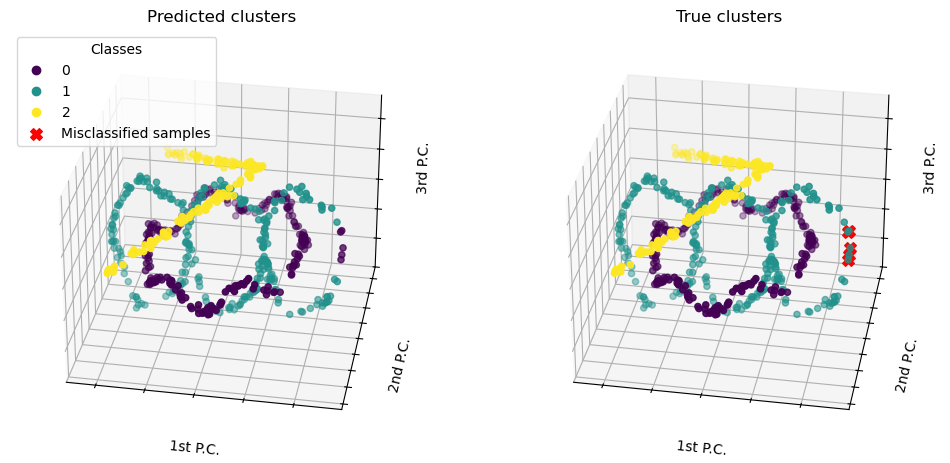

In [43]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2, projection="3d", elev=-150, azim=80)

scatter1 = ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)
ax1.set(title="Predicted clusters", xlabel="1st P.C.", ylabel="2nd P.C.", zlabel="3rd P.C.")
ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True)
ax2.set(title="True clusters", xlabel="1st P.C.", ylabel="2nd P.C.", zlabel="3rd P.C.")
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

miscl_mask = [y_hat != y]
scatter3 = ax2.scatter(
    data_reduced_3[miscl_mask[0], 0],
    data_reduced_3[miscl_mask[0], 1],
    data_reduced_3[miscl_mask[0], 2],
    c='r',
    depthshade=False,
    s=70,
    marker='X',
    #zorder=10,
    label='Misclassified samples')

handles1, labels1 = scatter1.legend_elements()
handles1.append(scatter3)
labels1.append('Misclassified samples')
ax1.legend(handles1, labels1, title="Classes", loc="upper left")

print(data_reduced_3[miscl_mask[0], 0].shape)

plt.tight_layout()
plt.show()

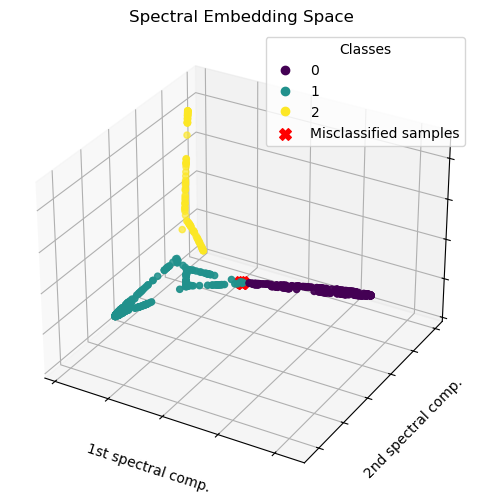

In [66]:
#--->visualise the embedding space:

se = SE(n_components=3, affinity='nearest_neighbors', n_neighbors=10) #---> exactly the same algorithm used inside SC 
embedding = se.fit_transform(scaled_data)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
scatter=ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], c=y)
scatter_m = ax.scatter(
    embedding[miscl_mask[0], 0],
    embedding[miscl_mask[0], 1],
    embedding[miscl_mask[0], 2],
    c='r',
    depthshade=False,
    s=70,
    marker='X',
    #zorder=10,
    label='Misclassified samples')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set(title="Spectral Embedding Space", xlabel="1st spectral comp.", ylabel="2nd spectral comp.", zlabel="3rd spectral comp.")
handles, labels = scatter.legend_elements()
handles.append(scatter_m)
labels.append('Misclassified samples')

ax.legend(handles, labels, title="Classes", loc="upper right")
plt.show()

In [36]:
# ---> TODO (all): review both technical (esp. spectral embedding) and plotting details?;
#      prettier graphs /code?
#      explain??